/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 193 (772.00 B)

 Trainable params: 193 (772.00 B)

 Non-trainable params: 0 (0.00 B)

Test Accuracy: 0.9825


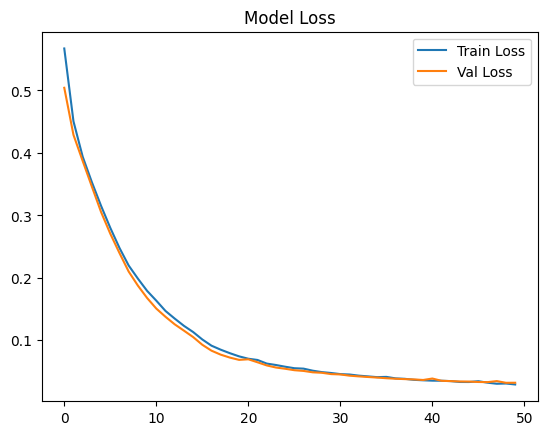

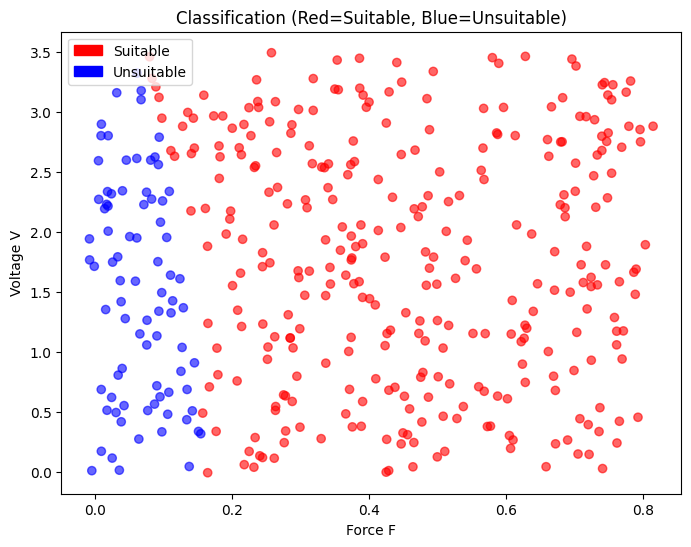

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt

# Parameters
L = 0.2
h = 0.01
w_beam = 0.01
E = 10**7
g = 0.05
I = (w_beam * h**3) / 12
n_samples = 2000

# Generate Random Input Data (F and V)
F_data = np.random.uniform(0, 0.8, (n_samples, 1))
V_data = np.random.uniform(0, 3.5, (n_samples, 1))
X = np.concatenate([F_data, V_data], axis=1)

# Add Noise to Inputs
X = X + np.random.uniform(-0.02, 0.02, X.shape)

# Analytical Solution for Deflection
dist_load = 0.1 * (X[:, 1]**2)
deflection = (dist_load * L**4) / (8 * E * I) + (X[:, 0] * L**3) / (3 * E * I)

# Classification Logic
# Suitable if gap < deflection < 6*gap
y = ((deflection > g) & (deflection < 6*g)).astype(int)

# Split Data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Model Definition
model = Sequential()
model.add(Dense(16, input_shape=(2,), activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='sigmoid')) # Sigmoid for binary classification

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()
# Training
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2, verbose=0)

# Evaluation
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {accuracy:.4f}")

# Plot Training History
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.legend()
plt.show()

# Decision Boundary
colors = ['red' if label == 1 else 'blue' for label in y_test]

plt.figure(figsize=(8, 6))
plt.scatter(X_test[:, 0], X_test[:, 1], c=colors, alpha=0.6)
plt.xlabel('Force F')
plt.ylabel('Voltage V')
plt.title('Classification (Red=Suitable, Blue=Unsuitable)')

# Legend
from matplotlib.patches import Patch
plt.legend(handles=[Patch(color='red', label='Suitable'),
                    Patch(color='blue', label='Unsuitable')])
plt.show()

